<a href="https://colab.research.google.com/github/Aya-ahmedd/DataAnalysis-ITI-/blob/main/StatBi(ITI)1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas openpyxl matplotlib seaborn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read CSV file
file_path = "sample_data/2.13.Practical-example.csv"

df = pd.read_csv(file_path, skiprows=4)

# Display first rows
df.head()

,Unnamed: 0,ID,Building,Year of sale,Month of sale,Type of property,Property #,Area (ft.),Price,Status,...,Y,M,D,Gender,Country,State,Purpose,Deal satisfaction,Mortgage,Source
0,NaN,1030.0,1.0,2005.0,11.0,Apartment,30.0,743.09,"$246,172.68",Sold,...,1986.0,6.0,21.0,F,USA,California,Home,5.0,No,Website
1,NaN,1029.0,1.0,2005.0,10.0,Apartment,29.0,756.21,"$246,331.90",Sold,...,1983.0,2.0,24.0,F,USA,California,Home,5.0,No,Website
2,NaN,2002.0,2.0,2007.0,7.0,Apartment,2.0,587.28,"$209,280.91",Sold,...,1985.0,12.0,27.0,M,USA,California,Home,1.0,Yes,Client
3,NaN,2031.0,2.0,2007.0,12.0,Apartment,31.0,1604.75,"$452,667.01",Sold,...,1985.0,12.0,27.0,M,USA,California,Investment,3.0,Yes,Website
4,NaN,1049.0,1.0,2004.0,11.0,Apartment,49.0,1375.45,"$467,083.31",Sold,...,1979.0,5.0,15.0,F,USA,California,Home,4.0,No,Agency


In [8]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (915, 27)

Columns:
['Unnamed: 0', 'ID', 'Building', 'Year of sale', 'Month of sale', 'Type of property', 'Property #', 'Area (ft.)', 'Price', 'Status', 'Unnamed: 10', 'Customer ID', 'Entity', 'Name', 'Surname', 'Age at time of purchase', 'Interval', 'Y', 'M', 'D', 'Gender', 'Country', 'State', 'Purpose', 'Deal satisfaction', 'Mortgage', 'Source']

Data Types:
Unnamed: 0                  object
ID                         float64
Building                   float64
Year of sale               float64
Month of sale              float64
Type of property            object
Property #                 float64
Area (ft.)                 float64
Price                       object
Status                      object
Unnamed: 10                float64
Customer ID                 object
Entity                      object
Name                        object
Surname                     object
Age at time of purchase     object
Interval                    object
Y                          float64


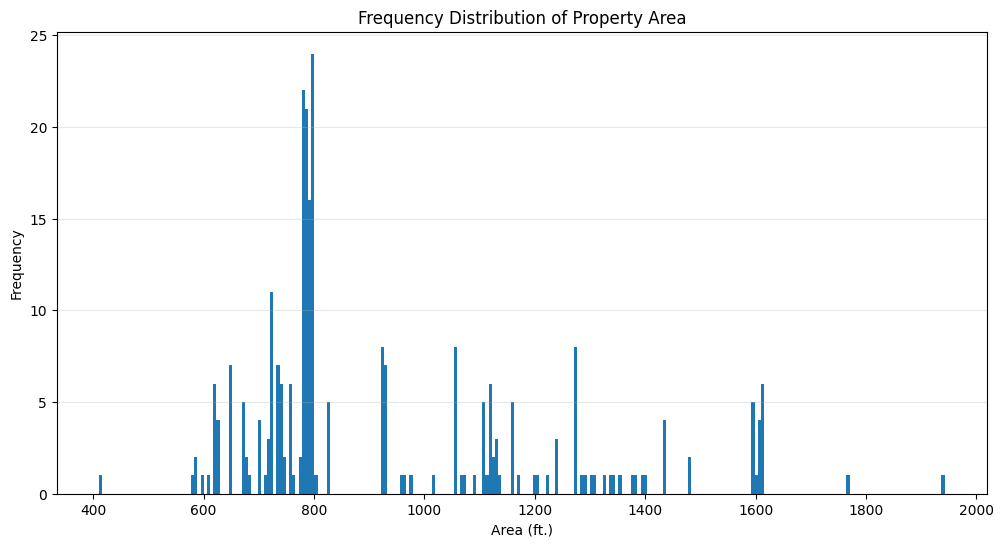

In [9]:
# Convert Area to numeric
df["Area (ft.)"] = pd.to_numeric(df["Area (ft.)"], errors="coerce")

# Remove missing Area values
area = df["Area (ft.)"].dropna()

# Histogram with 267 bins
plt.figure(figsize=(12, 6))

plt.hist(area, bins=267)

plt.title("Frequency Distribution of Property Area")
plt.xlabel("Area (ft.)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.show()

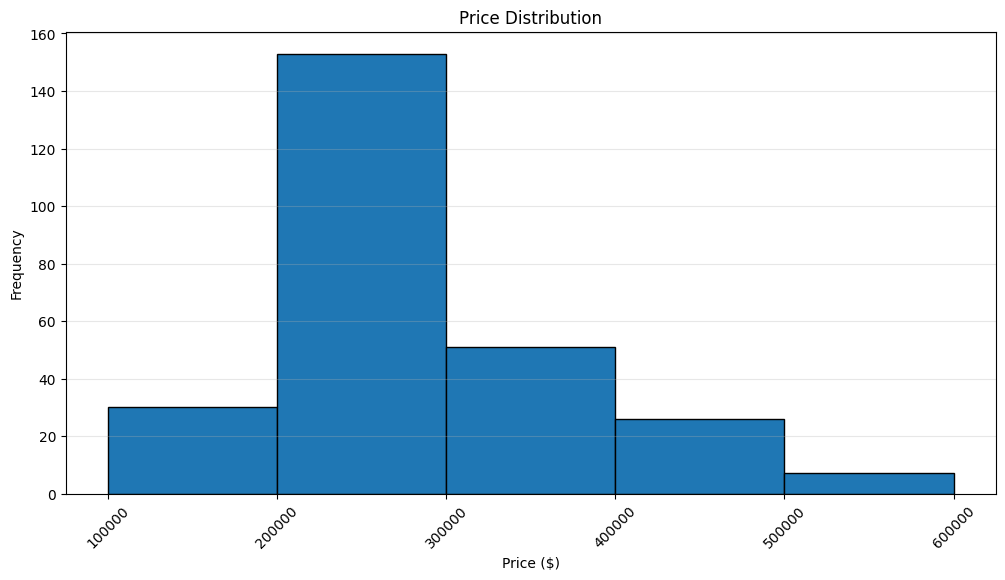

In [10]:
# Clean Price
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric
df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

# Remove missing prices
price = df["Price"].dropna()

# Create bins with width = $100,000
min_price = np.floor(price.min() / 100000) * 100000
max_price = np.ceil(price.max() / 100000) * 100000

bins = np.arange(
    min_price,
    max_price + 100000,
    100000
)

# Histogram
plt.figure(figsize=(12, 6))

plt.hist(
    price,
    bins=bins,
    edgecolor="black"
)

plt.title("Price Distribution")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")

plt.xticks(bins, rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

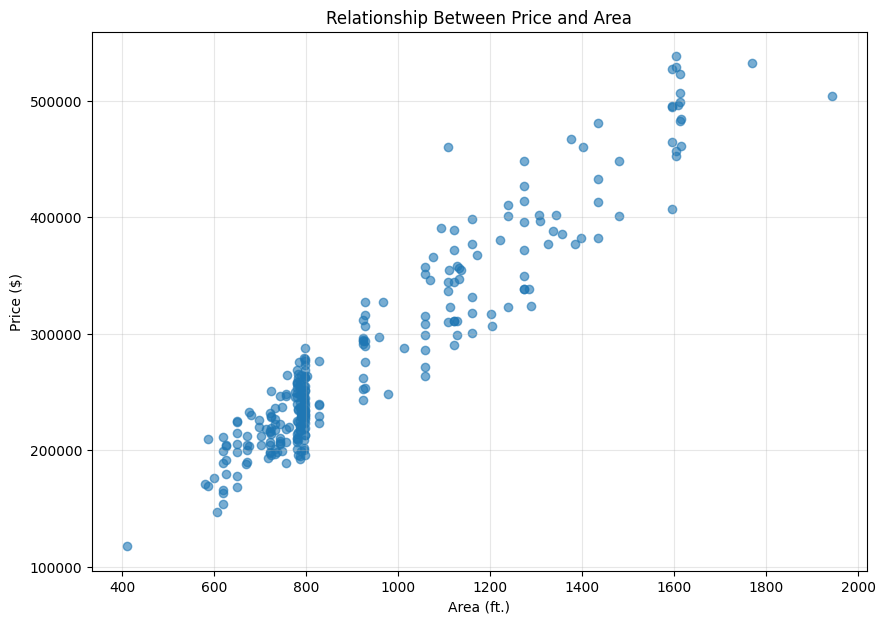

Correlation between Area and Price: 0.9511


In [12]:
# Remove rows with missing Area or Price
scatter_df = df.dropna(
    subset=["Area (ft.)", "Price"]
)

# Scatter plot
plt.figure(figsize=(10, 7))

plt.scatter(
    scatter_df["Area (ft.)"],
    scatter_df["Price"],
    alpha=0.6
)

plt.title("Relationship Between Price and Area")
plt.xlabel("Area (ft.)")
plt.ylabel("Price ($)")

plt.grid(alpha=0.3)

plt.show()

correlation = scatter_df["Area (ft.)"].corr(
    scatter_df["Price"]
)

print(f"Correlation between Area and Price: {correlation:.4f}")

In [13]:
correlation = scatter_df["Area (ft.)"].corr(
    scatter_df["Price"]
)

print(f"Correlation between Area and Price: {correlation:.4f}")

Correlation between Area and Price: 0.9511


In [19]:
country_frequency = df["Country"].value_counts()

print(country_frequency)

frequency_table = pd.DataFrame({
    "Country": country_frequency.index,
    "Absolute Frequency": country_frequency.values
})

frequency_table


Country
USA        177
Canada       7
Russia       4
UK           2
Belgium      2
Denmark      1
Germany      1
Mexico       1
Name: count, dtype: int64


,Country,Absolute Frequency
0,USA,177
1,Canada,7
2,Russia,4
3,UK,2
4,Belgium,2
5,Denmark,1
6,Germany,1
7,Mexico,1


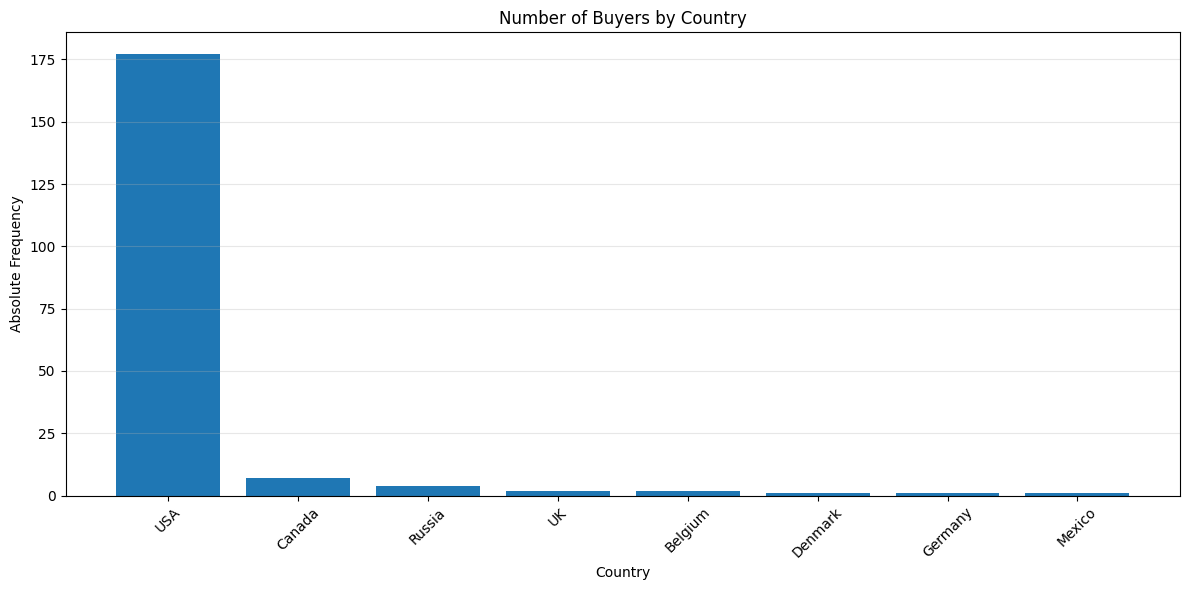

In [22]:

plt.figure(figsize=(12, 6))

plt.bar(
    frequency_table["Country"],
    frequency_table["Absolute Frequency"]
)

plt.title("Number of Buyers by Country")
plt.xlabel("Country")
plt.ylabel("Absolute Frequency")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [23]:
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

price = df["Price"].dropna()

# Mean
mean_price = price.mean()

# Median
median_price = price.median()

# Mode
mode_price = price.mode()

print(f"Mean Price   = ${mean_price:,.2f}")
print(f"Median Price = ${median_price:,.2f}")

print("\nMode Price:")

if len(mode_price) == 0:
    print("No Mode")
else:
    for mode in mode_price:
        print(f"${mode:,.2f}")

Mean Price   = $281,171.90
Median Price = $249,075.66

Mode Price:
$460,001.26
